# Installing/importing dependancies (libraries)

In [1]:
import numpy as np
import os
from collections import Counter , deque
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import kagglehub
import math
from torchvision import datasets, transforms
from torch.utils.data import Dataset , DataLoader, random_split
import torch.optim as optim
import torchvision.models as models
from PIL import Image
import random
import json

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA unavailable, Training on CPU ')

else:
    print('CUDA available, Training on GPU')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(1234)

CUDA available, Training on GPU


## Importing the dataset via kagglehub

Importing and analysis of the dataset to understand the structure, the file hierarchy

In [2]:
path = kagglehub.dataset_download("kmader/food41")
print("Path to dataset files:", path)
print("top-level contents:" , os.listdir(path))
print("Inside images:" , os.listdir(os.path.join(path,"images"))[:5],"...")
print("Inside 'meta':", os.listdir(os.path.join(path, "meta","meta")))


Path to dataset files: /kaggle/input/datasets/kmader/food41
top-level contents: ['meta', 'food_test_c101_n1000_r64x64x3.h5', 'food_c101_n10099_r32x32x3.h5', 'food_c101_n1000_r384x384x3.h5', 'food_test_c101_n1000_r128x128x3.h5', 'images', 'food_test_c101_n1000_r32x32x3.h5', 'food_test_c101_n1000_r32x32x1.h5', 'food_test_c101_n1000_r128x128x1.h5', 'food_c101_n10099_r64x64x1.h5', 'food_c101_n10099_r64x64x3.h5', 'food_test_c101_n1000_r64x64x1.h5', 'food_c101_n10099_r32x32x1.h5']
Inside images: ['macarons', 'french_toast', 'lobster_bisque', 'prime_rib', 'pork_chop'] ...
Inside 'meta': ['test.txt', 'train.json', 'labels.txt', 'test.json', 'train.txt', 'classes.txt']


In [3]:
#Reading the given official class names list

with open(os.path.join(path , "meta" , "meta" , "classes.txt")) as f:
    classes = [line.strip() for line in f]

classes_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

print("="*50)
print(f"total classes: {len(classes)}")
print("="*50)
print(f"classes to integer mapping: {classes_to_idx}")


total classes: 101
classes to integer mapping: {'apple_pie': 0, 'baby_back_ribs': 1, 'baklava': 2, 'beef_carpaccio': 3, 'beef_tartare': 4, 'beet_salad': 5, 'beignets': 6, 'bibimbap': 7, 'bread_pudding': 8, 'breakfast_burrito': 9, 'bruschetta': 10, 'caesar_salad': 11, 'cannoli': 12, 'caprese_salad': 13, 'carrot_cake': 14, 'ceviche': 15, 'cheesecake': 16, 'cheese_plate': 17, 'chicken_curry': 18, 'chicken_quesadilla': 19, 'chicken_wings': 20, 'chocolate_cake': 21, 'chocolate_mousse': 22, 'churros': 23, 'clam_chowder': 24, 'club_sandwich': 25, 'crab_cakes': 26, 'creme_brulee': 27, 'croque_madame': 28, 'cup_cakes': 29, 'deviled_eggs': 30, 'donuts': 31, 'dumplings': 32, 'edamame': 33, 'eggs_benedict': 34, 'escargots': 35, 'falafel': 36, 'filet_mignon': 37, 'fish_and_chips': 38, 'foie_gras': 39, 'french_fries': 40, 'french_onion_soup': 41, 'french_toast': 42, 'fried_calamari': 43, 'fried_rice': 44, 'frozen_yogurt': 45, 'garlic_bread': 46, 'gnocchi': 47, 'greek_salad': 48, 'grilled_cheese_sand

In [4]:
#reading the official train/test split files from the meta folder to get the benchmark train/test splits and replicate these

def read_split_file(split_name):
    with open(os.path.join(path ,"meta","meta", f"{split_name}.txt")) as f:
        return [line.strip() for line in f]

train_files = read_split_file("train")
test_files = read_split_file("test")

print(f"Official train size: {len(train_files)}")
print(f"Official test size:  {len(test_files)}")
print(f"Example entry: {train_files[0]}")

Official train size: 75750
Official test size:  25250
Example entry: apple_pie/1005649


# Exploratory data analysis (EDA)

In [5]:
counts_in_train = Counter(entry.split("/")[0] for entry in train_files)
counts_in_test = Counter(entry.split("/")[0] for entry in test_files)
print("="*50)
print(f"Number of classes in train: {len(counts_in_train)}")
print("="*50)
print(f"Min images per class (train): {min(counts_in_train.values())}")
print(f"Max images per class (train): {max(counts_in_train.values())}")
print(f"Min images per class (test):  {min(counts_in_test.values())}")
print(f"Max images per class (test):  {max(counts_in_test.values())}")
print("="*50)
# Show the 5 smallest and 5 largest classes
sorted_counts = sorted(counts_in_train.items(), key=lambda x: x[1])
print("\n5 smallest classes (train):", sorted_counts[:5])
print("="*50)
print("5 largest classes (train):", sorted_counts[-5:])
print("="*50)

Number of classes in train: 101
Min images per class (train): 750
Max images per class (train): 750
Min images per class (test):  250
Max images per class (test):  250

5 smallest classes (train): [('apple_pie', 750), ('baby_back_ribs', 750), ('baklava', 750), ('beef_carpaccio', 750), ('beef_tartare', 750)]
5 largest classes (train): [('tacos', 750), ('takoyaki', 750), ('tiramisu', 750), ('tuna_tartare', 750), ('waffles', 750)]


**checking image dimensions and for corrupted data**

In [6]:
random.seed(1234)

samples = random.sample(train_files, 200)

widths , heights = [] , []
corrupt_files = []

for relv_pth in samples:
    img_pth = os.path.join(path , "images", relv_pth + ".jpg")
    try:
        with Image.open(img_pth) as im:
            w, h = im.size
            widths.append(w)
            heights.append(h)

    except Exception as e:
        corrupt_files.append((relv_pth. str(e)))

print(f"Sampled {len(samples)} images")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)/len(widths):.0f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)/len(heights):.0f}")
print(f"Corrupt/unreadable files: {len(corrupt_files)}")
if corrupt_files:
    print("First few:", corrupt_files[:3])
            

Sampled 200 images
Width  — min: 289, max: 512, avg: 498
Height — min: 287, max: 512, avg: 471
Corrupt/unreadable files: 0


**Visual Inspection of the data**

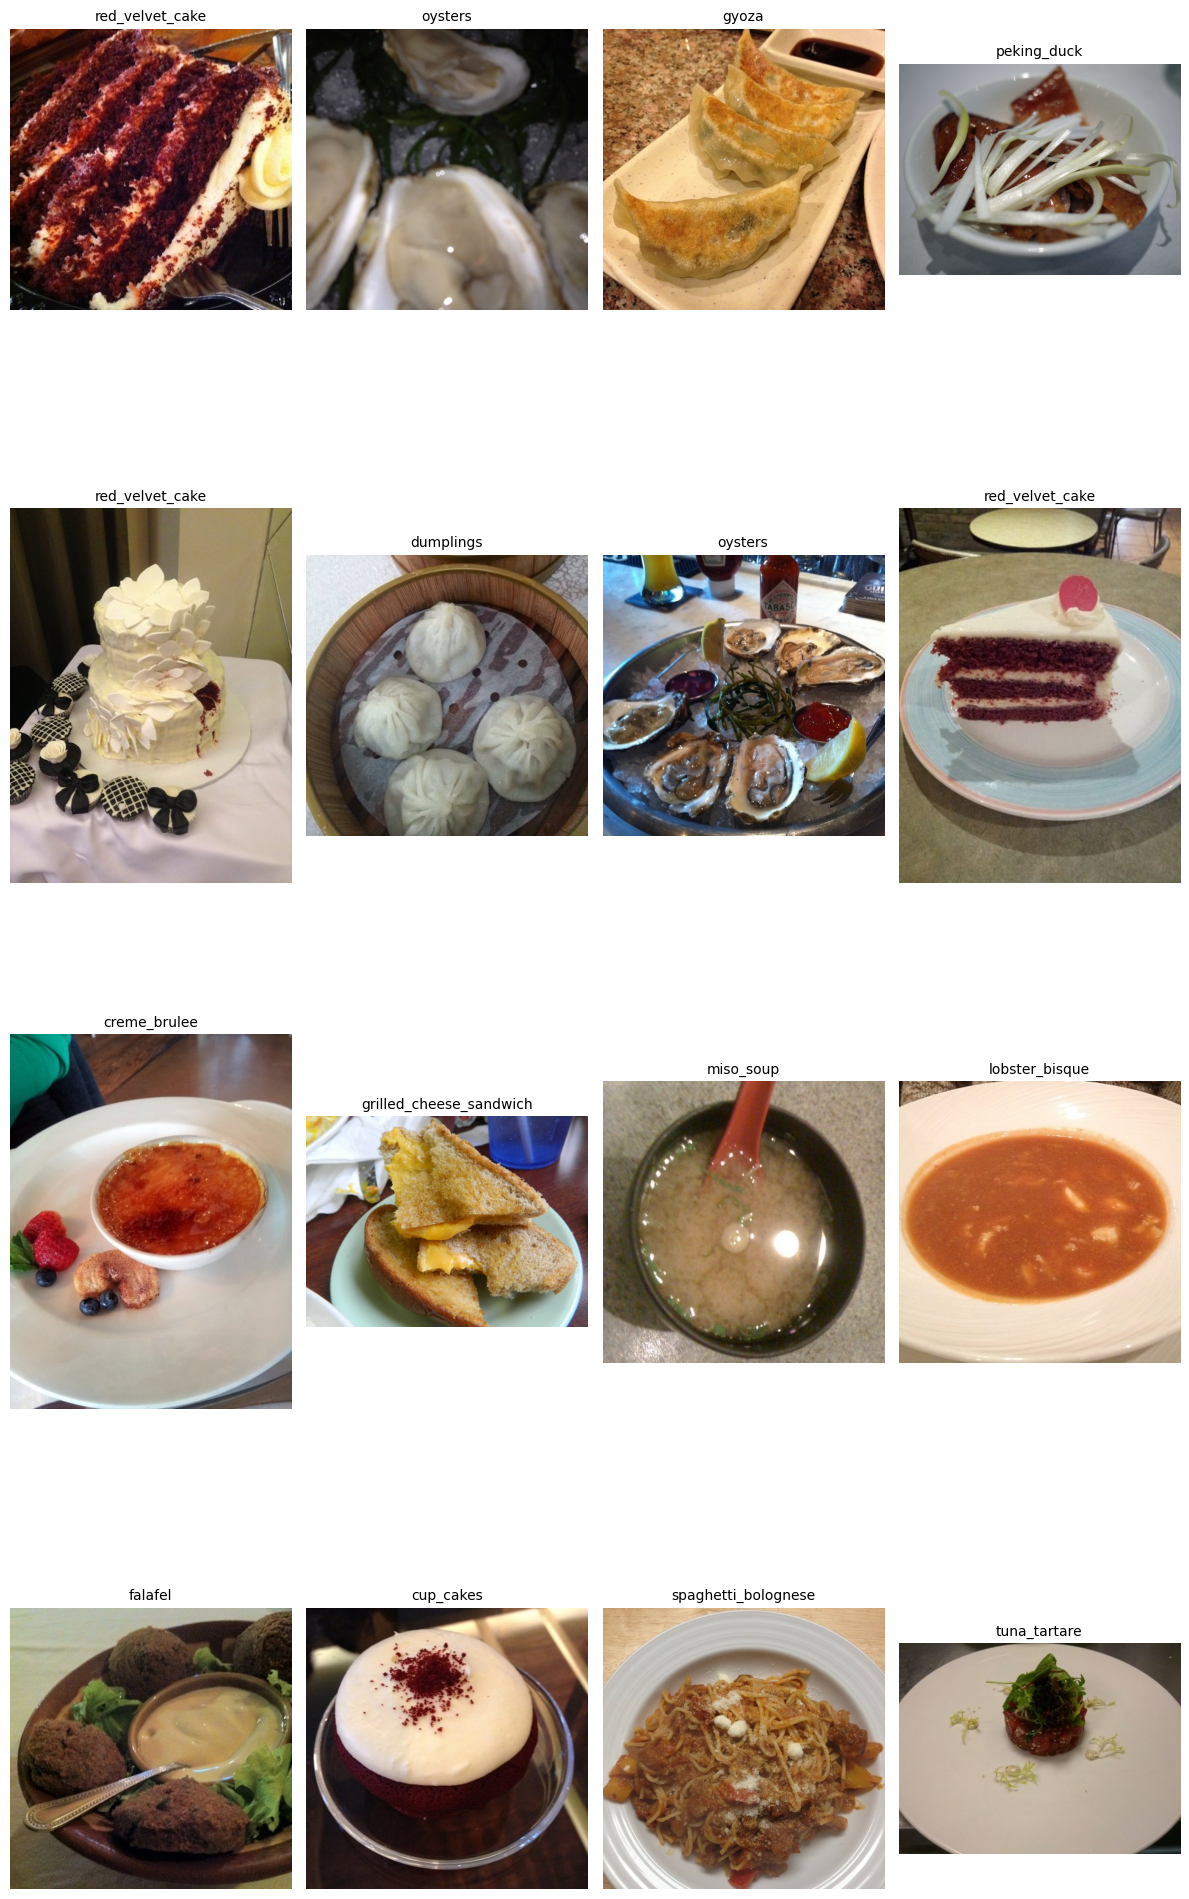

In [7]:
to_show = random.sample(train_files , 16)

fig , axes = plt.subplots(4,4 , figsize=(12,22))

for ax , relv_pth in zip(axes.flat , to_show):
    class_name = relv_pth.split("/")[0]
    img_pth = os.path.join(path , "images", relv_pth + ".jpg")
    img = Image.open(img_pth)
    ax.imshow(img)
    ax.set_title(class_name , fontsize=10)
    ax.axis("off")

plt.tight_layout()
plt.show()

**Creation of the validation set**

In [8]:
random.seed(1234)

#shuffling a copy of the train set in order to avoid mutation of the training files
ss_shuffled = train_files.copy()
random.shuffle(ss_shuffled)

val_size = int(0.1 * len(ss_shuffled))
val_files = ss_shuffled[:val_size]
train_files_final = ss_shuffled[val_size:]

print(f"Train (final):  {len(train_files_final)}")
print(f"Val:            {len(val_files)}")
print(f"Test (held out): {len(test_files)}")

Train (final):  68175
Val:            7575
Test (held out): 25250


**Applying transformations seperate for both training and validation sets**

In [9]:
img_dims = 224
image_mean = [0.485 , 0.456, 0.406]
image_std = [0.229 , 0.224 , 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256),                    # shorter side -> 256
    transforms.RandomResizedCrop(img_dims),    # random crop + resize to 224
    transforms.RandomHorizontalFlip(),         # mirror left/right (is food symmetric enough)
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),     # simulate different lighting
    transforms.ToTensor(),                      # PIL -> tensor, scales to [0,1]
    transforms.Normalize(image_mean, image_std),
])

vals_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(img_dims),
    transforms.ToTensor(),
    transforms.Normalize(image_mean , image_std)
])


**Defining a custom dataset clas**

In [10]:
class Food101Dataset(Dataset):
    def __init__(self,file_lst, root_dir, class_to_idx,transform=None):
        self.file_lst = file_lst
        self.root_dir = root_dir
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.file_lst)

    def __getitem__(self,idx):
        relv_pth = self.file_lst[idx]
        class_name = relv_pth.split("/")[0]
        label = self.class_to_idx[class_name]

        img_pth = os.path.join(self.root_dir , relv_pth + ".jpg")
        ss_img = Image.open(img_pth).convert("RGB")

        if self.transform:
            ss_img = self.transform(ss_img)

        return ss_img , label

**Instantiation of the three datasets**

In [11]:
imgs_root = os.path.join(path,"images")

train_ds = Food101Dataset(train_files_final,imgs_root,classes_to_idx,transform=train_transform)
val_ds = Food101Dataset(val_files,imgs_root,classes_to_idx,transform=vals_transform)
test_ds = Food101Dataset(test_files,imgs_root,classes_to_idx,transform=vals_transform)

print(f"Train: {len(train_ds)}")
print(f"Val:   {len(val_ds)}")
print(f"Test:  {len(test_ds)}")

img, label = train_ds[0]
print(f"Sample image tensor shape: {img.shape}") 
print(f"Sample label: {label} ({classes[label]})")

            

Train: 68175
Val:   7575
Test:  25250
Sample image tensor shape: torch.Size([3, 224, 224])
Sample label: 60 (lobster_bisque)


**Wrapping into dataloaders:** so we get batched items 

In [12]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_ds,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
    
)

val_loader = DataLoader(
    val_ds,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = NUM_WORKERS,
    pin_memory = True
    
)

test_loader = DataLoader(
    test_ds,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = NUM_WORKERS,
    pin_memory = True
    
)

images_batch, labels_batch = next(iter(train_loader))
print(f"Batch images shape: {images_batch.shape}")   
print(f"Batch labels shape: {labels_batch.shape}") 

Batch images shape: torch.Size([32, 3, 224, 224])
Batch labels shape: torch.Size([32])


In [13]:
with open("classes.json", "w") as f:
    json.dump(classes, f)

print("Saved class list to classes.json")

Saved class list to classes.json


## **Training Phase**

**Using EfficientNet B0**

In [14]:
NUM_CLASSES = 101

ss_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

print("original classifier:")
print(ss_model.classifier)

original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [15]:
#replacing the models last layer to hold only the logits needed for the food_101 classification

ss_model.classifier[1] = nn.Linear(in_features=1280 , out_features=NUM_CLASSES)
print("=====Modified classifier=====")
print(ss_model.classifier)

ss_model = ss_model.to(device)

=====Modified classifier=====
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=101, bias=True)
)


In [16]:
#defining the training optimisers and loss function
ss_criterion = nn.CrossEntropyLoss()
ss_optim = optim.AdamW(ss_model.parameters(), lr=0.0001)

In [17]:
ss_epochs = 8

ss_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ss_optim,
    T_max = ss_epochs,
    eta_min = 0.000001
)

ss_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

Best_model_pth = "best_food101_effnet_b0.pth"
best_val_acc = 0.0

print(f"Scheduler: CosineAnnealingLR over {ss_epochs} epochs")
print(f"Starting LR: {ss_optim.param_groups[0]['lr']}")
print(f"Final LR (eta_min): 0.000001")
print(f"Best model will be saved to: {Best_model_pth}")

Scheduler: CosineAnnealingLR over 8 epochs
Starting LR: 0.0001
Final LR (eta_min): 0.000001
Best model will be saved to: best_food101_effnet_b0.pth


In [18]:
for e in range(ss_epochs):
    #training phase
    ss_model.train()
    running_loss = 0.0
    trained_correct = 0
    tot_trained = 0

    for btch_idx, (images , labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        ss_optim.zero_grad()
        ss_logits = ss_model(images)
        ss_loss = ss_criterion(ss_logits , labels)
        ss_loss.backward()
        ss_optim.step()

        running_loss += ss_loss.item() * images.size(0)
        preds = ss_logits.argmax(dim=1)
        trained_correct += (preds == labels).sum().item()
        tot_trained += labels.size(0)

        if (btch_idx + 1) % 100 == 0:
            avg_loss = running_loss / tot_trained
            avg_acc = trained_correct / tot_trained
            print(f"Epoch {e+1}/{ss_epochs} | Batch {btch_idx+1}/{len(train_loader)} "
                  f"| Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f}")

    train_loss = running_loss / tot_trained
    train_acc = trained_correct / tot_trained

    # Validation phase
    ss_model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    total_val = 0

    with torch.no_grad():
        for images , labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            ss_logits = ss_model(images)
            ss_loss = ss_criterion(ss_logits , labels)

            val_loss_sum += ss_loss.item() * images.size(0)
            preds = ss_logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_loss = val_loss_sum / total_val
    val_acc = val_correct / total_val

    current_lr = ss_optim.param_groups[0]['lr']
    ss_scheduler.step()

    # logging metrics
    ss_history["train_loss"].append(train_loss)
    ss_history["train_acc"].append(train_acc)
    ss_history["val_loss"].append(val_loss)
    ss_history["val_acc"].append(val_acc)
    ss_history["lr"].append(current_lr)

    #saving best model logic
    is_improved = val_acc > best_val_acc
    if is_improved:
        best_val_acc = val_acc
        torch.save(ss_model.state_dict() , Best_model_pth)


    #Epoch summary
    flag = "New best model saved!" if is_improved else ""
    print(f"\n=== Epoch {e+1}/{ss_epochs} complete ===")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Val loss:   {val_loss:.4f} | Val acc:   {val_acc:.4f}{flag}")
    print(f"LR used this epoch: {current_lr:.6f}\n")

print(f"Training finished. Best val accuracy: {best_val_acc:.4f}")
print(f"Best model weights saved to: {Best_model_pth}")
        

Epoch 1/8 | Batch 100/2131 | Loss: 4.5389 | Train Acc: 0.0419
Epoch 1/8 | Batch 200/2131 | Loss: 4.3983 | Train Acc: 0.0833
Epoch 1/8 | Batch 300/2131 | Loss: 4.1793 | Train Acc: 0.1321
Epoch 1/8 | Batch 400/2131 | Loss: 3.9702 | Train Acc: 0.1686
Epoch 1/8 | Batch 500/2131 | Loss: 3.7859 | Train Acc: 0.2011
Epoch 1/8 | Batch 600/2131 | Loss: 3.6213 | Train Acc: 0.2278
Epoch 1/8 | Batch 700/2131 | Loss: 3.4786 | Train Acc: 0.2529
Epoch 1/8 | Batch 800/2131 | Loss: 3.3580 | Train Acc: 0.2742
Epoch 1/8 | Batch 900/2131 | Loss: 3.2494 | Train Acc: 0.2936
Epoch 1/8 | Batch 1000/2131 | Loss: 3.1504 | Train Acc: 0.3113
Epoch 1/8 | Batch 1100/2131 | Loss: 3.0591 | Train Acc: 0.3273
Epoch 1/8 | Batch 1200/2131 | Loss: 2.9800 | Train Acc: 0.3410
Epoch 1/8 | Batch 1300/2131 | Loss: 2.9122 | Train Acc: 0.3525
Epoch 1/8 | Batch 1400/2131 | Loss: 2.8458 | Train Acc: 0.3650
Epoch 1/8 | Batch 1500/2131 | Loss: 2.7837 | Train Acc: 0.3759
Epoch 1/8 | Batch 1600/2131 | Loss: 2.7322 | Train Acc: 0.3850
E

**Second model using ConvNext tiny:**
Using a second model to see if validation accuracy improves to further strengthen the 60 seconds posting claim

In [19]:
ss_model2 = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)

print("Original ConvNeXt-Tiny classifier:")
print(ss_model2.classifier)

NUM_CLASSES = 101
ss_model2.classifier[2] = nn.Linear(in_features=768, out_features=NUM_CLASSES)

print("\nModified classifier for Food-101:")
print(ss_model2.classifier)

ss_model2 = ss_model2.to(device)

# Sanity check: forward a dummy batch to confirm shapes and device
dumm_inp = torch.randn(2, 3, 224, 224).to(device)
dumm_op = ss_model2(dumm_inp)
print(f"\nOutput shape: {dumm_op.shape}")  
print(f"Model device: {next(ss_model2.parameters()).device}")  

Original ConvNeXt-Tiny classifier:
Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=1000, bias=True)
)

Modified classifier for Food-101:
Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=101, bias=True)
)

Output shape: torch.Size([2, 101])
Model device: cuda:0


In [20]:
ss_m2_criterion = nn.CrossEntropyLoss()
ss_m2_optim = optim.AdamW(ss_model2.parameters(), lr=5e-5)

ss_epchs = 8
m2_scheduler = optim.lr_scheduler.CosineAnnealingLR(
    ss_m2_optim,
    T_max=ss_epchs,
    eta_min=1e-6,
)

m2_history = {
    "train_loss": [],
    "train_acc":  [],
    "val_loss":   [],
    "val_acc":    [],
    "lr":         [],
}

m2_bst_pth = "best_food101_convnext.pth"
m2_best_val_acc = 0.0

print(f"Model: ConvNeXt-Tiny ({sum(p.numel() for p in ss_model2.parameters())/1e6:.1f}M params)")
print(f"Optimizer: AdamW, starting LR = 5e-5")
print(f"Scheduler: CosineAnnealingLR over {ss_epchs} epochs, eta_min=1e-6")
print(f"Best model will be saved to: {m2_bst_pth}")

Model: ConvNeXt-Tiny (27.9M params)
Optimizer: AdamW, starting LR = 5e-5
Scheduler: CosineAnnealingLR over 8 epochs, eta_min=1e-6
Best model will be saved to: best_food101_convnext.pth


In [21]:
window = 50

for e in range(ss_epchs):
    # ---- Training phase ----
    ss_model2.train()
    loss_window = deque(maxlen=window)
    correct_window = deque(maxlen=window)
    count_window = deque(maxlen=window)
    epch_loss_sum = 0.0
    epch_correct = 0
    epch_total = 0

    for btch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        ss_m2_optim.zero_grad()
        logits = ss_model2(images)
        loss = ss_m2_criterion(logits, labels)
        loss.backward()
        ss_m2_optim.step()

        batch_loss = loss.item()
        preds = logits.argmax(dim=1)
        batch_correct = (preds == labels).sum().item()
        batch_size = labels.size(0)

        loss_window.append(batch_loss * batch_size)
        correct_window.append(batch_correct)
        count_window.append(batch_size)

        epch_loss_sum += batch_loss * batch_size
        epch_correct += batch_correct
        epch_total += batch_size

        if (btch_idx + 1) % 100 == 0:
            window_loss = sum(loss_window) / sum(count_window)
            window_acc = sum(correct_window) / sum(count_window)
            print(f"Epoch {e+1}/{ss_epchs} | Batch {btch_idx+1}/{len(train_loader)} "
                  f"| Loss (last {window}): {window_loss:.4f} "
                  f"| Acc (last {window}): {window_acc:.4f}")

    train_loss = epch_loss_sum / epch_total
    train_acc = epch_correct / epch_total

    # ---- Validation phase ----
    ss_model2.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            logits = ss_model2(images)
            loss = ss_m2_criterion(logits, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc = val_correct / val_total

    # ---- Scheduler step (read current LR first, then step) ----
    curr_lr = ss_m2_optim.param_groups[0]['lr']
    m2_scheduler.step()

    # ---- Log to history ----
    m2_history["train_loss"].append(train_loss)
    m2_history["train_acc"].append(train_acc)
    m2_history["val_loss"].append(val_loss)
    m2_history["val_acc"].append(val_acc)
    m2_history["lr"].append(curr_lr)

    # ---- Save best model ----
    improved = val_acc > m2_best_val_acc
    if improved:
        m2_best_val_acc = val_acc
        torch.save(ss_model2.state_dict(), m2_bst_pth)

    # ---- Epoch summary ----
    flag = "  <-- new best, saved" if improved else ""
    print(f"\n=== Epoch {e+1}/{ss_epchs} complete ===")
    print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"Val loss:   {val_loss:.4f} | Val acc:   {val_acc:.4f}{flag}")
    print(f"LR used this epoch: {curr_lr:.6f}\n")

print(f"Training finished. Best val accuracy: {m2_best_val_acc:.4f}")
print(f"Best model weights saved to: {m2_bst_pth}")

Epoch 1/8 | Batch 100/2131 | Loss (last 50): 4.3635 | Acc (last 50): 0.0819
Epoch 1/8 | Batch 200/2131 | Loss (last 50): 3.7116 | Acc (last 50): 0.2769
Epoch 1/8 | Batch 300/2131 | Loss (last 50): 3.2050 | Acc (last 50): 0.3556
Epoch 1/8 | Batch 400/2131 | Loss (last 50): 2.8050 | Acc (last 50): 0.4206
Epoch 1/8 | Batch 500/2131 | Loss (last 50): 2.5109 | Acc (last 50): 0.4662
Epoch 1/8 | Batch 600/2131 | Loss (last 50): 2.2385 | Acc (last 50): 0.5156
Epoch 1/8 | Batch 700/2131 | Loss (last 50): 2.1393 | Acc (last 50): 0.5200
Epoch 1/8 | Batch 800/2131 | Loss (last 50): 1.9856 | Acc (last 50): 0.5500
Epoch 1/8 | Batch 900/2131 | Loss (last 50): 1.8376 | Acc (last 50): 0.5894
Epoch 1/8 | Batch 1000/2131 | Loss (last 50): 1.7678 | Acc (last 50): 0.6006
Epoch 1/8 | Batch 1100/2131 | Loss (last 50): 1.7530 | Acc (last 50): 0.6075
Epoch 1/8 | Batch 1200/2131 | Loss (last 50): 1.6351 | Acc (last 50): 0.6019
Epoch 1/8 | Batch 1300/2131 | Loss (last 50): 1.5708 | Acc (last 50): 0.6269
Epoch 1/

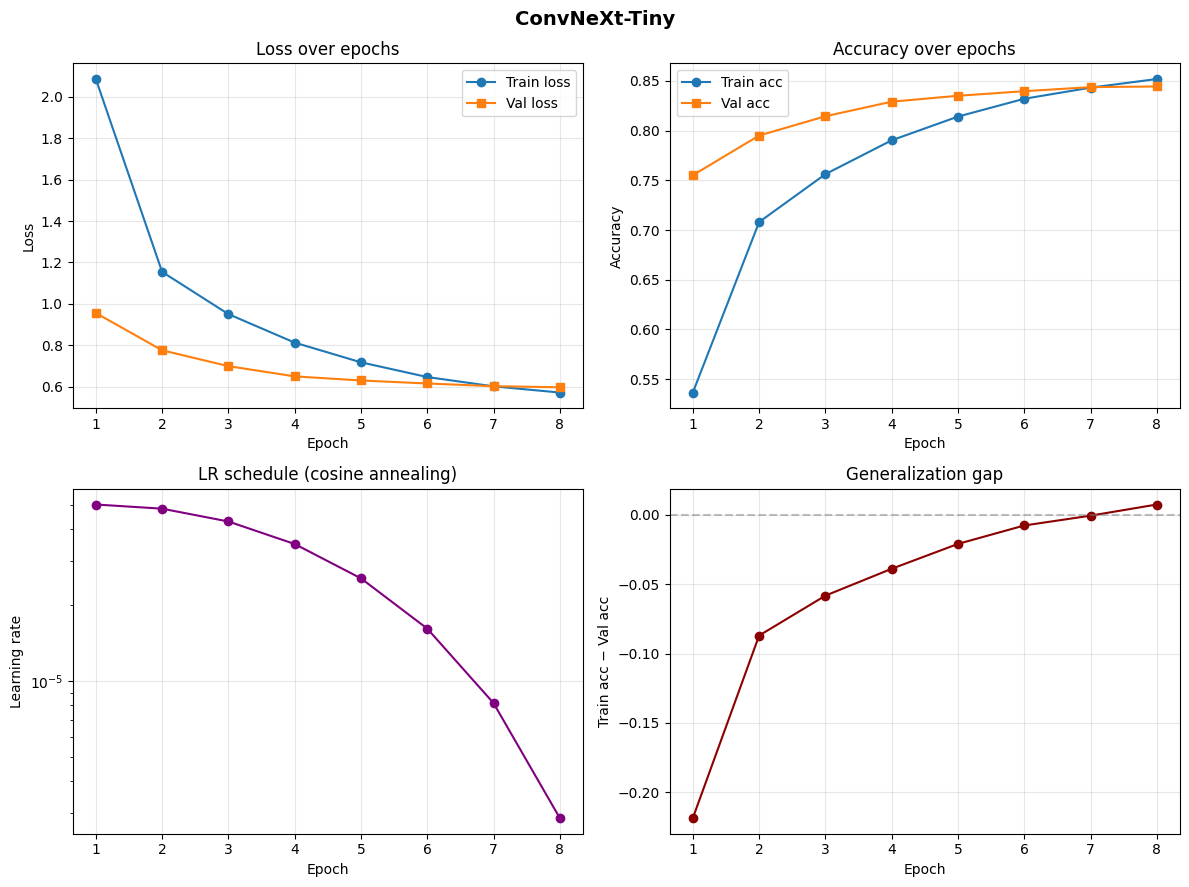

In [22]:


def plot_history(history, title_prefix):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))

    # Loss curves
    axes[0, 0].plot(epochs, history["train_loss"], "o-", label="Train loss")
    axes[0, 0].plot(epochs, history["val_loss"], "s-", label="Val loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")
    axes[0, 0].set_title("Loss over epochs")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Accuracy curves
    axes[0, 1].plot(epochs, history["train_acc"], "o-", label="Train acc")
    axes[0, 1].plot(epochs, history["val_acc"], "s-", label="Val acc")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].set_title("Accuracy over epochs")
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Learning rate schedule
    axes[1, 0].plot(epochs, history["lr"], "o-", color="purple")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].set_ylabel("Learning rate")
    axes[1, 0].set_title("LR schedule (cosine annealing)")
    axes[1, 0].set_yscale("log")
    axes[1, 0].grid(True, alpha=0.3)

    # Train/val accuracy gap (overfitting indicator)
    gap = [t - v for t, v in zip(history["train_acc"], history["val_acc"])]
    axes[1, 1].plot(epochs, gap, "o-", color="darkred")
    axes[1, 1].axhline(0, color="gray", linestyle="--", alpha=0.5)
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].set_ylabel("Train acc − Val acc")
    axes[1, 1].set_title("Generalization gap")
    axes[1, 1].grid(True, alpha=0.3)

    fig.suptitle(title_prefix, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_history(m2_history, "ConvNeXt-Tiny")

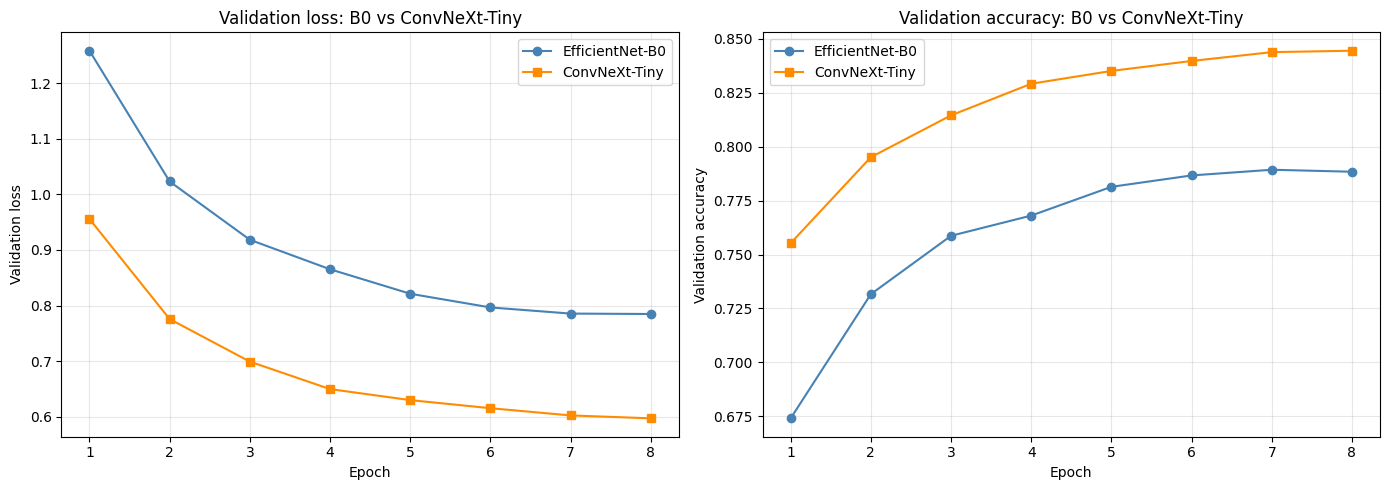

EfficientNet-B0 best val acc:  0.7893
ConvNeXt-Tiny best val acc:    0.8445
Absolute improvement:          +0.0552


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_b0 = range(1, len(ss_history["val_acc"]) + 1)
epochs_cn = range(1, len(m2_history["val_acc"]) + 1)

# Val loss comparison
axes[0].plot(epochs_b0, ss_history["val_loss"], "o-", label="EfficientNet-B0", color="steelblue")
axes[0].plot(epochs_cn, m2_history["val_loss"], "s-", label="ConvNeXt-Tiny", color="darkorange")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Validation loss")
axes[0].set_title("Validation loss: B0 vs ConvNeXt-Tiny")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Val accuracy comparison
axes[1].plot(epochs_b0, ss_history["val_acc"], "o-", label="EfficientNet-B0", color="steelblue")
axes[1].plot(epochs_cn, m2_history["val_acc"], "s-", label="ConvNeXt-Tiny", color="darkorange")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Validation accuracy")
axes[1].set_title("Validation accuracy: B0 vs ConvNeXt-Tiny")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print headline numbers for the writeup
print(f"EfficientNet-B0 best val acc:  {max(ss_history['val_acc']):.4f}")
print(f"ConvNeXt-Tiny best val acc:    {max(m2_history['val_acc']):.4f}")
print(f"Absolute improvement:          {max(m2_history['val_acc']) - max(ss_history['val_acc']):+.4f}")